In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import data

device = torch.device('cuda')
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3090


In [ ]:
# ===== Configuration =====
mouse_id    = 3
data_path   = '../data'
weight_path = './checkpoints/vit_frozen'
os.makedirs(weight_path, exist_ok=True)

import os

HF_TOKEN = os.getenv("HF_TOKEN")                                 # <-- fill in your HuggingFace token
MODEL_NAME = 'facebook/dinov3-vits16-pretrain-lvd1689m' # ViT-Small, ~21M params

# --- Token & layer config ---
TOKEN_TYPE     = 'patch'   # 'patch': spatial readout  |  'cls': global/linear readout
EXTRACT_LAYERS = [4]      # None = last layer; e.g. [8,9,10,11] = last 4 of 12 blocks

# --- Training config ---
MAX_EPOCHS = 200   # hard upper limit; early stopping will usually kick in sooner
PATIENCE   = 5     # epochs without varexp improvement → reduce LR (at patience//2), stop (at patience)

np.random.seed(1)

In [4]:
# Load full 66×264 images WITHOUT normalization.
# We normalize AFTER spatial preprocessing so the z-score stats are
# computed on the same pixels the model will actually see.
img = data.load_images(data_path, mouse_id, file=data.img_file_name[mouse_id],
                       crop=False, normalize=False)
print('raw img shape:', img.shape, '  dtype:', img.dtype,
      '  range: [%.1f, %.1f]' % (img.min(), img.max()))

raw image shape:  (68000, 66, 264)
img:  (68000, 66, 264) 0.0 255.0 float32
raw img shape: (68000, 66, 264)   dtype: float32   range: [0.0, 255.0]


In [5]:
# ===== Image preprocessing: 66×264 → (N, 3, 32, 64), ImageNet-normalized =====
# Pipeline:
#   1. Resize  66×264  →  64×256  (bilinear)
#   2. Crop left half  →  64×128
#   3. Downsample 2×   →  32×64   (bilinear)
#   4. Per-image [0, 1] normalization
#   5. Repeat to 3 channels (grayscale → pseudo-RGB)
#   6. ImageNet normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
from utils.vit_encoding_model import preprocess_images

img = preprocess_images(img, batch_size=2000)

print('preprocessed img shape:', img.shape)
print('  mean=%.4f  std=%.4f  range=[%.2f, %.2f]' % (img.mean(), img.std(), img.min(), img.max()))

/home/carsen/anaconda3/envs/minimodel-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


preprocessed img shape: (68000, 3, 64, 128)
  mean=0.1492  std=1.1445  range=[-2.12, 2.64]


In [6]:
# Load neurons
fname = '%s_nat60k_%s.npz' % (data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(
    file_path=os.path.join(data_path, fname), mouse_id=mouse_id
)
n_stim, n_neurons = spks.shape


loading activities from ../data/FX10_nat60k_2023_05_16.npz


In [7]:
# Split train / validation
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)


splitting training and validation set...
itrain:  (30559,)
ival:  (3396,)


In [8]:
# Normalize neural data
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)
print('spks shape:', spks.shape)
print('spks_rep_all shape:', spks_rep_all.shape)


normalizing neural data...
finished
spks shape: (33955, 4792)
spks_rep_all shape: (500, 10, 4792)


In [9]:
# Prepare tensors
ineur = np.arange(0, n_neurons)
spks_train = torch.from_numpy(spks[itrain][:, ineur])
spks_val   = torch.from_numpy(spks[ival][:, ineur])

# Images: (N, 3, 32, 64) already from preprocess_images()
img_train = torch.from_numpy(img[istim_train][itrain]).to(device)
img_val   = torch.from_numpy(img[istim_train][ival]).to(device)
img_test  = torch.from_numpy(img[istim_test]).to(device)

print('spks_train:', spks_train.shape, spks_train.min().item(), spks_train.max().item())
print('spks_val:  ', spks_val.shape, spks_val.min().item(), spks_val.max().item())
print('img_train: ', img_train.shape, img_train.min().item(), img_train.max().item())
print('img_test:  ', img_test.shape)

spks_train: torch.Size([30559, 4792]) 0.0 45.76918029785156
spks_val:   torch.Size([3396, 4792]) 0.0 40.468990325927734
img_train:  torch.Size([30559, 3, 64, 128]) -2.1179039478302 2.640000104904175
img_test:   torch.Size([500, 3, 64, 128])


In [10]:
# ===== Build ViT model (frozen backbone) =====
from utils.vit_encoding_model import build_vit_encoder, make_model_name

# vit_input_size=(112, 224): ViT internal input; aspect ratio 0.5 matches 32×64.
#   Gives 7×14 patch grid (patch_size=16).
# out_spatial_size=(16, 32): upsample patch features to 2× downsampled model input,
#   matching the CNN convention (pool 2× from 32×64 → 16×32).
#   Set to None to use the native 7×14 patch grid instead.
# token_type: 'patch' uses spatial patch tokens; 'cls' uses the global CLS token.

model = build_vit_encoder(
    n_neurons        = len(ineur),
    model_name       = MODEL_NAME,
    vit_input_size   = (64, 128),   # ViT internal resize (H, W), divisible by 16
    out_spatial_size = (4, 8),     # readout resolution (half of 32×64 model input)
    extract_layers   = EXTRACT_LAYERS,
    use_channel_proj = False,
    proj_dim         = 64,
    freeze_backbone  = True,
    poisson          = True,
    hf_token         = HF_TOKEN,
    device           = device,
)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 6219.55it/s]

ViTCore: facebook/dinov3-vits16-pretrain-lvd1689m
  patch_size=16 embed_dim=384, register_tokens=4
  ViT input: (64, 128)  →  spatial output: 4x8
  out_channels=384, out_spatial_size=(4, 8)
  frozen=True
Readout in_shape (C, Ly, Lx): (384, 4, 8)
Total: 23,498,968 | Trainable: 1,902,424 | Frozen: 21,596,544


In [ ]:
# ===== Train readout (frozen backbone) =====
from utils.vit_encoding_model import train_readout

# Model name encodes: mouse, date, ViT variant, token type, layers used
model_filename = make_model_name(
    data.mouse_names[mouse_id], data.exp_date[mouse_id],
    MODEL_NAME, TOKEN_TYPE, EXTRACT_LAYERS,
)
model_path = os.path.join(weight_path, model_filename)
print('Checkpoint:', model_path)

if not os.path.exists(model_path):
    best_state = train_readout(
        model,
        spks_train, spks_val,
        img_train,  img_val,
        max_epochs = MAX_EPOCHS,
        batch_size = 64,
        lr         = 1e-3,
        l2_readout = 0.1,
        clamp      = True,
        patience   = PATIENCE,
        device     = device,
    )
    torch.save(best_state, model_path)
    print('Saved:', model_path)
else:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print('Loaded:', model_path)


Checkpoint: ./checkpoints/vit_frozen/FX10_051623_dinov3_vits16_patch_l5.pt
Training readout | max_epochs=200, patience=5, lr=1.0e-03
  epoch   0 | train 0.8826 | val 54.3685 | varexp 0.0088 | lr 1.0e-03 | patience 0/5 | 8.9s
  epoch   1 | train 0.8592 | val 53.7100 | varexp 0.0233 | lr 1.0e-03 | patience 0/5 | 16.7s
  epoch   2 | train 0.8499 | val 53.2609 | varexp 0.0336 | lr 1.0e-03 | patience 0/5 | 24.7s
  epoch   3 | train 0.8435 | val 52.9564 | varexp 0.0407 | lr 1.0e-03 | patience 0/5 | 32.5s
  epoch   4 | train 0.8392 | val 52.7644 | varexp 0.0455 | lr 1.0e-03 | patience 0/5 | 40.9s
  epoch   5 | train 0.8364 | val 52.6375 | varexp 0.0487 | lr 1.0e-03 | patience 0/5 | 49.6s
  epoch   6 | train 0.8345 | val 52.5497 | varexp 0.0509 | lr 1.0e-03 | patience 0/5 | 58.4s
  epoch   7 | train 0.8331 | val 52.4870 | varexp 0.0525 | lr 1.0e-03 | patience 0/5 | 67.3s
  epoch   8 | train 0.8321 | val 52.4346 | varexp 0.0540 | lr 1.0e-03 | patience 0/5 | 76.3s
  epoch   9 | train 0.8312 | va

In [ ]:
# ===== Evaluate: FEVE on test set =====
from utils import metrics, model_trainer
# ViT model predictions
model.eval()
n_test   = img_test.shape[0]
vit_pred = []
with torch.no_grad():
    for k in range(0, n_test, 64):
        pred = model(img_test[k:k+64])
        vit_pred.append(pred.cpu().numpy())
vit_pred = np.vstack(vit_pred)
print('vit_pred:', vit_pred.shape, vit_pred.min(), vit_pred.max())

vit_pred: (500, 4792) 0.02060628 4.298309


In [ ]:
# FEVE metric
vit_fev, vit_feve = metrics.feve(spks_rep_all, vit_pred)

threshold = 0.15
valid = np.where(vit_fev > threshold)[0]
print(f'Valid neurons (FEV > {threshold}): {len(valid)} / {len(vit_fev)}')
print(f'FEVE (test, ViT frozen): {np.mean(vit_feve[vit_fev > threshold]):.4f}')

Valid neurons (FEV > 0.15): 3040 / 4792
FEVE (test, ViT frozen): 0.3010


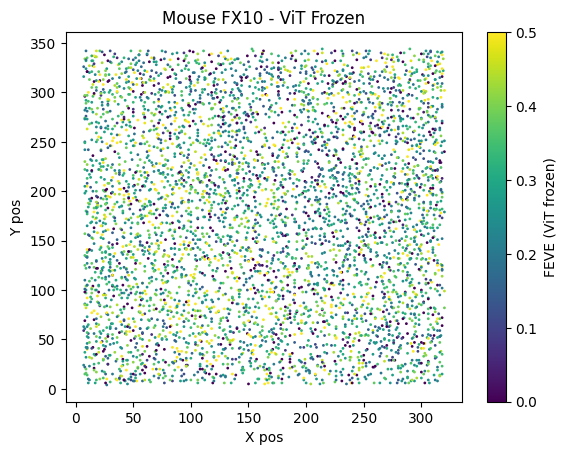

In [ ]:
plt.scatter(xpos , ypos, c=vit_feve, cmap='viridis', s=1, vmin=0, vmax=0.5)
plt.colorbar(label='FEVE (ViT frozen)')
plt.title(f'Mouse {data.mouse_names[mouse_id]} - ViT Frozen')
plt.xlabel('X pos')
plt.ylabel('Y pos')
plt.show()  

In [ ]:
end

NameError: name 'end' is not defined

In [ ]:
# ===== (Optional) Compare with CNN model =====
from utils import model_builder

cnn_weight_path = '../notebooks/checkpoints/fullmodel'
cnn_model, in_channels = model_builder.build_model(
    NN=len(ineur), n_layers=2, n_conv=16, n_conv_mid=320
)
cnn_model_name = model_builder.create_model_name(
    data.mouse_names[mouse_id], data.exp_date[mouse_id],
    n_layers=2, in_channels=in_channels
)
cnn_model_path = os.path.join(cnn_weight_path, cnn_model_name)

if os.path.exists(cnn_model_path):
    cnn_model.load_state_dict(torch.load(cnn_model_path, map_location='cpu'))
    cnn_model = cnn_model.to(device)

    cnn_pred = model_trainer.test_epoch(cnn_model, img_test)
    cnn_fev, cnn_feve = metrics.feve(spks_rep_all, cnn_pred)

    print(f'FEVE (CNN):        {np.mean(cnn_feve[cnn_fev > threshold]):.4f}')
    print(f'FEVE (ViT frozen): {np.mean(vit_feve[vit_fev > threshold]):.4f}')
else:
    print(f'CNN model not found at {cnn_model_path} — skipping comparison')
    cnn_pred = None

core shape:  torch.Size([1, 320, 33, 65])
input shape of readout:  (320, 33, 65)
model name:  FX10_051623_2layer_16_320_clamp_norm_depthsep_pool.pt


RuntimeError: Given groups=1, weight of size [16, 1, 25, 25], expected input[100, 3, 64, 128] to have 1 channels, but got 3 channels instead

In [ ]:
# ===== Plot comparison =====
if cnn_pred is not None:
    # Per-neuron correlation coefficient
    def cc_per_neuron(pred, target):
        cc = np.array([
            np.corrcoef(pred[:, i], target[:, i])[0, 1]
            for i in range(pred.shape[1])
        ])
        return cc

    spks_test_np = spks_rep_all.mean(1)  # mean over repeats
    cnn_cc = cc_per_neuron(cnn_pred, spks_test_np)
    vit_cc = cc_per_neuron(vit_pred, spks_test_np)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter: CNN vs ViT frozen
    ax = axes[0]
    ax.scatter(cnn_cc, vit_cc, alpha=0.3, s=6, c='steelblue')
    lim = max(np.nanmax(np.abs(cnn_cc)), np.nanmax(np.abs(vit_cc))) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4)
    ax.set_xlabel('CNN minimodel CC')
    ax.set_ylabel('ViT frozen CC')
    ax.set_title(f'Frozen backbone\nMedian ΔCC = {np.nanmedian(vit_cc - cnn_cc):.3f}')
    ax.set_aspect('equal')

    # Histogram of ΔCC
    ax = axes[1]
    ax.hist(vit_cc - cnn_cc, bins=60, color='steelblue', alpha=0.7)
    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('ΔCC (ViT frozen − CNN)')
    ax.set_ylabel('# neurons')
    ax.set_title('Improvement distribution')

    plt.tight_layout()
    plt.savefig(os.path.join(weight_path, 'comparison_frozen.png'), dpi=150)
    plt.show()